# DLWA Analysis: GC-free vs Host-triggered GC

Comparing two zone management strategies on ZNS SSD (ConfZNS++) across different `finish_threshold` values.

- **GC-free** (`gc_mode=False`): zone finished early, no host GC, higher DLWA
- **Host GC** (`gc_mode=True`): delayed FINISH, GC mixes data by lifetime, lower DLWA but GC overhead

In [1]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv("../results/pages_to_write_2M.csv")
df

,gc_mode,finish_threshold,total_pages_to_write,finish_call_count,latency_micros_per_op,throughput_MB_per_s,timestamp
0,False,0,0,0,26.130,38.0,2026-04-17 10:13:56
1,False,10,90119,4,26.897,36.9,2026-04-17 10:14:55
2,False,20,77336,3,25.692,38.6,2026-04-17 10:15:51
3,False,25,342510,4,26.673,37.2,2026-04-17 10:16:49
4,False,30,1005288,8,25.951,38.2,2026-04-17 10:17:46
5,False,40,669755,8,24.891,39.8,2026-04-17 10:18:41
6,False,50,1608380,9,25.537,38.8,2026-04-17 10:19:38
7,False,55,5660615,25,37.364,26.5,2026-04-17 10:20:59
8,False,60,7468278,30,44.251,22.4,2026-04-17 10:22:33
9,False,70,6198796,25,38.343,25.9,2026-04-17 10:23:55


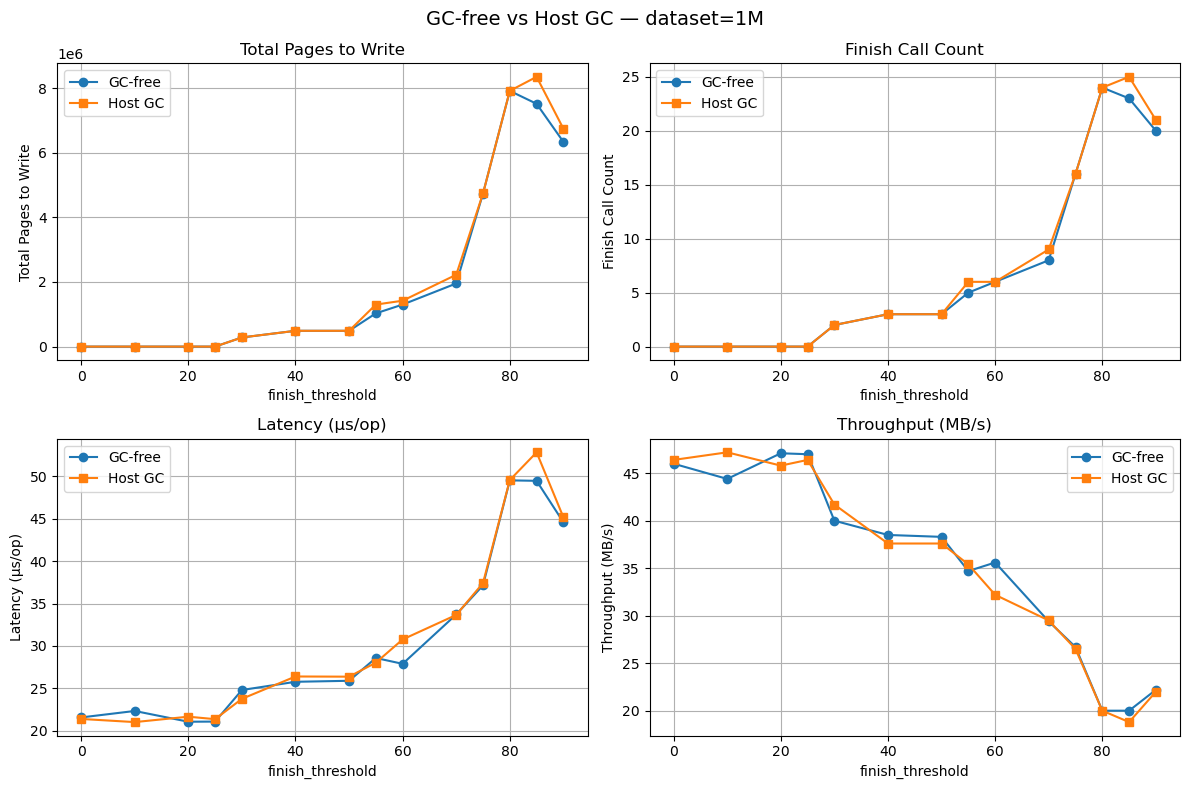

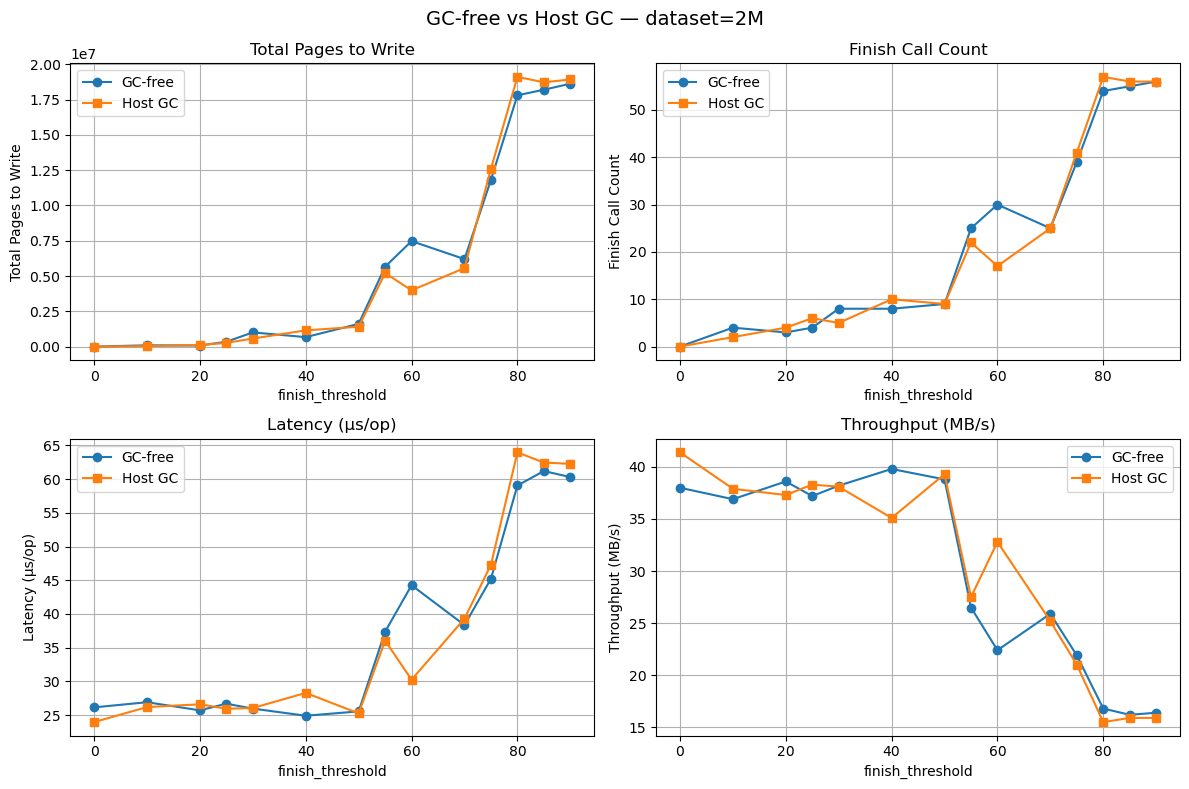

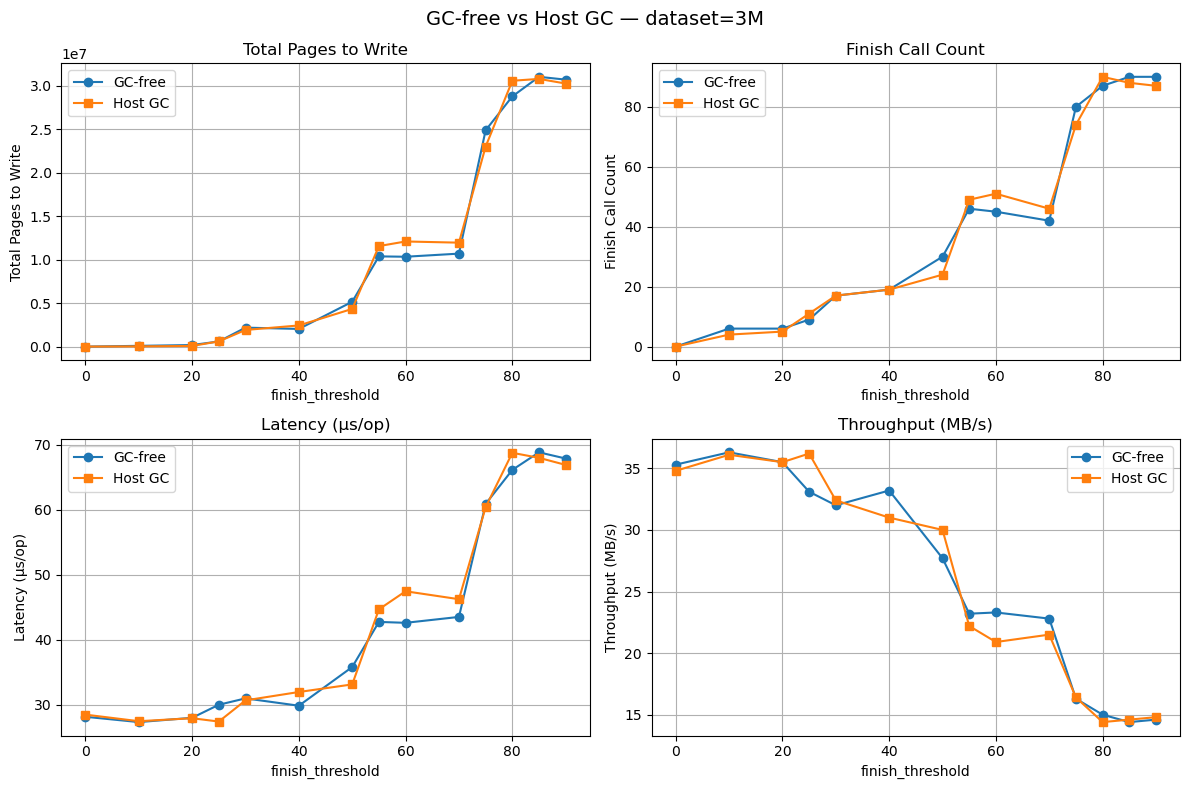

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

datasets = {
    "1M":  "../results/pages_to_write_1M.csv",
    "2M":  "../results/pages_to_write_2M.csv",
    "3M":  "../results/pages_to_write_3M.csv",
}

metrics = [
    ("total_pages_to_write", "Total Pages to Write"),
    ("finish_call_count",    "Finish Call Count"),
    ("latency_micros_per_op","Latency (µs/op)"),
    ("throughput_MB_per_s",  "Throughput (MB/s)"),
]

for dataset_name, path in datasets.items():
    data = pd.read_csv(path)
    gc_false = data[data["gc_mode"] == False]
    gc_true  = data[data["gc_mode"] == True]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"GC-free vs Host GC — dataset={dataset_name}", fontsize=14)

    for ax, (col, label) in zip(axes.flat, metrics):
        ax.plot(gc_false["finish_threshold"], gc_false[col], marker="o", label="GC-free")
        ax.plot(gc_true["finish_threshold"],  gc_true[col],  marker="s", label="Host GC")
        ax.set_xlabel("finish_threshold")
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()
